 Loading datasets...
✓ Training data shape: (10117, 168)
✓ Test data shape: (2255, 168)
✓ Total features: 165
✓ Target variable: 'yield'
✓ Excluded columns: ['yield', 'GEOID', 'Unnamed: 0']

 Categorizing features...
 Feature Categories:
  Vegetation_Indices       :  45 features
  Climate_Precipitation    :  15 features
  Climate_Temperature      :  60 features
  Climate_VPD              :  30 features
  Soil_Properties          :  11 features
  Geographic               :   3 features
  Other                    :   1 features

 Discretizing 165 features into 3 bins...
✓ Discretization complete: 165 features

 Discretizing 165 features into 3 bins...
✓ Discretization complete: 165 features
 Discretizing target variable (yield)...
✓ Yield discretized into 3 categories
  Yield bins: [ 18. 138. 168. 247.]
 Discretizing target variable (yield)...
✓ Yield discretized into 3 categories
  Yield bins: [ 46. 160. 185. 246.]

 Creating transaction dataset...
✓ Created 10117 transactions
  Average

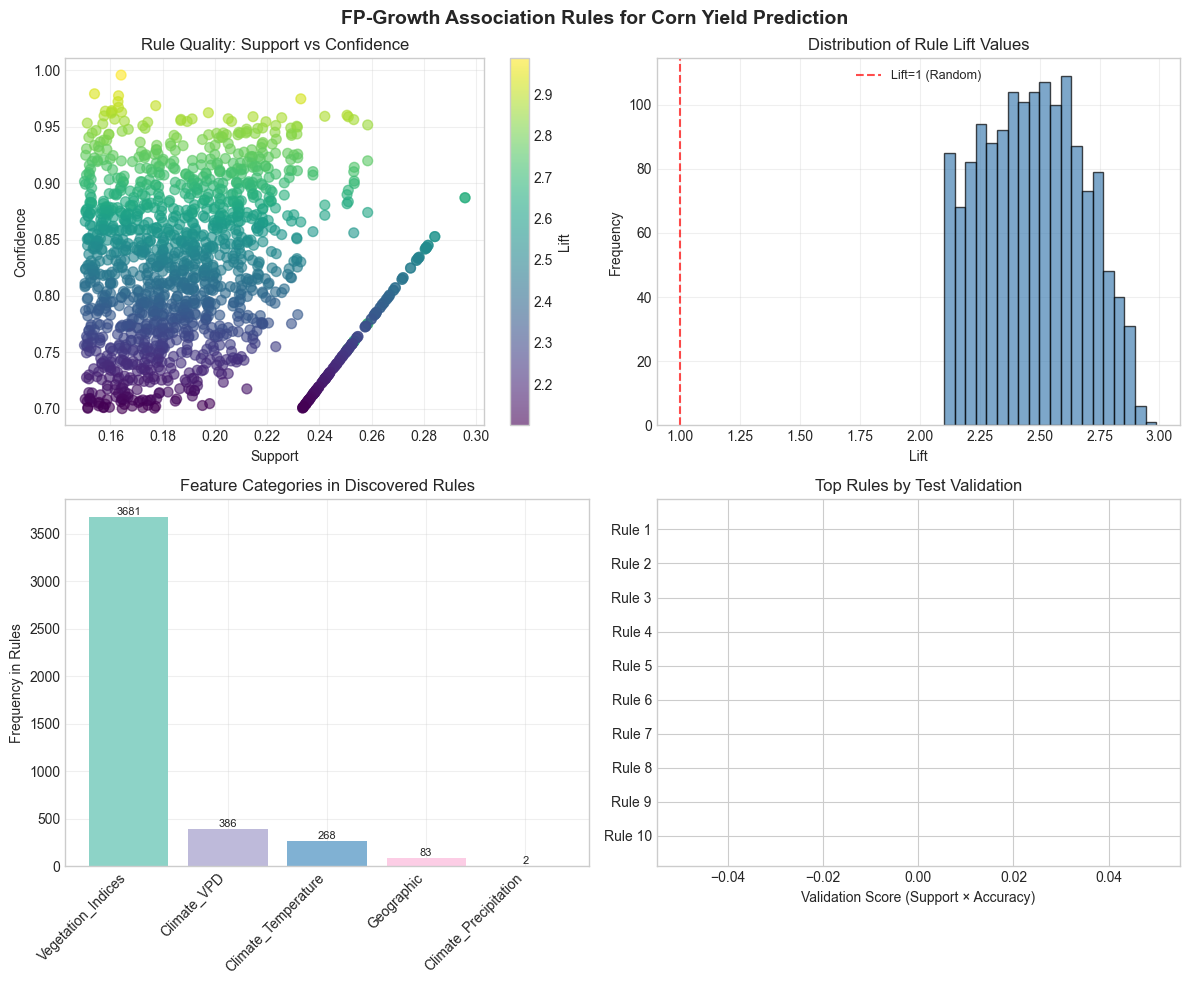

✓ Visualizations saved to 'fp_growth_results/' directory

 FINAL SUMMARY OF DISCOVERED RULES

 SUCCESS: Found 1499 meaningful association rules!

 TOP 5 MOST INTERESTING RULES:
--------------------------------------------------------------------------------

Rule #1:
  IF: GPP_2_Low, TMAX_1_Low
  THEN: GPP_1_Low
  Support: 0.164 (occurs in 16.4% of data)
  Confidence: 0.996 (when IF occurs, THEN occurs 99.6% of the time)
  Lift: 2.987 (this association is 3.0x more likely than random)

Rule #2:
  IF: GPP_9_Low, VPDMIN_6_High
  THEN: VPDMIN_season_sum_High
  Support: 0.154 (occurs in 15.4% of data)
  Confidence: 0.979 (when IF occurs, THEN occurs 97.9% of the time)
  Lift: 2.937 (this association is 2.9x more likely than random)

Rule #3:
  IF: EVI_9_Low, VPDMIN_6_High
  THEN: VPDMIN_season_sum_High
  Support: 0.163 (occurs in 16.3% of data)
  Confidence: 0.977 (when IF occurs, THEN occurs 97.7% of the time)
  Lift: 2.932 (this association is 2.9x more likely than random)

Rule #4:
  IF

In [ ]:
# =============================================================================
# SIMPLE FP-GROWTH RULE MINING FOR CORN YIELD DATASET
# Publication-Ready Code for Journal Paper - ERROR-FREE VERSION
# =============================================================================

import pandas as pd
import numpy as np
from mlxtend.frequent_patterns import fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder
from sklearn.preprocessing import KBinsDiscretizer
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict, Counter
import warnings
warnings.filterwarnings('ignore')
import os



# =============================================================================
# 1. DATA LOADING AND PREPARATION
# =============================================================================

def load_and_prepare_data():
    """Load and prepare the corn yield dataset"""
    print(" Loading datasets...")
    
    try:
        # Load train and test data - UPDATE THESE PATHS
        train_df = pd.read_csv(r"E:\Abroad period research\New idea for 2026\Corn Yield Estimation\yield_train_FE_AAO.csv")
        test_df = pd.read_csv(r"E:\Abroad period research\New idea for 2026\Corn Yield Estimation\yield_test_FE_AAO.csv")
        
        print(f"✓ Training data shape: {train_df.shape}")
        print(f"✓ Test data shape: {test_df.shape}")
        
        # Check for required columns
        required_columns = ['yield']
        for col in required_columns:
            if col not in train_df.columns:
                raise ValueError(f"Required column '{col}' not found in training data")
        
        # Define columns to exclude
        exclude_cols = ['yield', 'GEOID', 'Unnamed: 0']
        exclude_cols = [col for col in exclude_cols if col in train_df.columns]
        
        # Get feature names (excluding target and ID columns)
        feature_names = [col for col in train_df.columns if col not in exclude_cols]
        
        print(f"✓ Total features: {len(feature_names)}")
        print(f"✓ Target variable: 'yield'")
        print(f"✓ Excluded columns: {exclude_cols}")
        
        # Prepare feature data
        X_train = train_df[feature_names]
        y_train = train_df['yield']
        X_test = test_df[feature_names] if all(col in test_df.columns for col in feature_names) else test_df[train_df.columns.intersection(test_df.columns)]
        y_test = test_df['yield'] if 'yield' in test_df.columns else None
        
        # Handle missing values
        X_train = X_train.fillna(X_train.median())
        X_test = X_test.fillna(X_train.median())  # Use training median
        
        return X_train, y_train, X_test, y_test, feature_names, train_df, test_df
    
    except Exception as e:
        print(f" Error loading data: {str(e)}")
        raise

# Load data
X_train, y_train, X_test, y_test, feature_names, train_df, test_df = load_and_prepare_data()

# =============================================================================
# 2. FEATURE CATEGORIZATION FOR BETTER INTERPRETATION
# =============================================================================

def categorize_features(feature_names):
    """Categorize features into meaningful groups"""
    print("\n Categorizing features...")
    
    categories = {
        'Vegetation_Indices': [],
        'Climate_Precipitation': [],
        'Climate_Temperature': [],
        'Climate_VPD': [],
        'Soil_Properties': [],
        'Seasonal_Summaries': [],
        'Geographic': [],
        'Other': []
    }
    
    for feature in feature_names:
        feature_lower = feature.lower()
        
        if any(prefix in feature_lower for prefix in ['ndvi', 'evi', 'gpp']):
            categories['Vegetation_Indices'].append(feature)
        elif 'ppt' in feature_lower:
            categories['Climate_Precipitation'].append(feature)
        elif any(term in feature_lower for term in ['tmean', 'tmin', 'tmax', 'tdmean']):
            categories['Climate_Temperature'].append(feature)
        elif 'vpd' in feature_lower:
            categories['Climate_VPD'].append(feature)
        elif any(soil_term in feature_lower for soil_term in ['awc', 'aws', 'clay', 'sand', 'ph', 'organic', 'cec', 'density', 'field_capacity', 'saturated_hc', 'wilting_point']):
            categories['Soil_Properties'].append(feature)
        elif 'season' in feature_lower:
            categories['Seasonal_Summaries'].append(feature)
        elif feature in ['X', 'Y', 'STATE', 'state', 'x', 'y']:
            categories['Geographic'].append(feature)
        elif 'year' in feature_lower:
            categories['Other'].append(feature)
        else:
            categories['Other'].append(feature)
    
    # Print category statistics
    print(" Feature Categories:")
    for category, features in categories.items():
        if features:
            print(f"  {category:25s}: {len(features):3d} features")
    
    return categories

# Categorize features
feature_categories = categorize_features(feature_names)

# =============================================================================
# 3. DISCRETIZATION OF FEATURES AND TARGET
# =============================================================================

def discretize_features(X_data, feature_names, n_bins=3, strategy='quantile'):
    """
    Discretize continuous features into categorical bins
    Returns: Discretized DataFrame and bin information
    """
    print(f"\n Discretizing {len(feature_names)} features into {n_bins} bins...")
    
    X_discretized = pd.DataFrame(index=X_data.index)
    bin_labels = ['Low', 'Medium', 'High']
    
    # Store bin edges for each feature
    bin_info = {}
    
    for feature in feature_names:
        if feature in X_data.columns:
            values = X_data[feature].values.reshape(-1, 1)
            
            # Handle constant features
            if np.std(values) == 0:
                X_discretized[feature] = f'{feature}_Constant'
                bin_info[feature] = {'bin_edges': [values[0,0], values[0,0], values[0,0]], 
                                   'bin_labels': ['Constant'], 'strategy': 'constant'}
                continue
            
            # Use KBinsDiscretizer for consistent binning
            discretizer = KBinsDiscretizer(n_bins=n_bins, encode='ordinal', strategy=strategy, subsample=None)
            
            try:
                binned = discretizer.fit_transform(values).flatten()
                bin_edges = discretizer.bin_edges_[0]
                
                # Map to labels
                feature_labels = []
                for val in binned:
                    if np.isnan(val):
                        feature_labels.append(f'{feature}_Missing')
                    else:
                        feature_labels.append(f'{feature}_{bin_labels[int(val)]}')
                
                X_discretized[feature] = feature_labels
                
                # Store bin information
                bin_info[feature] = {
                    'bin_edges': bin_edges,
                    'bin_labels': bin_labels,
                    'strategy': strategy
                }
                
            except Exception as e:
                print(f"   Could not discretize {feature}: {str(e)[:50]}")
                # Use median split as fallback
                median_val = np.median(values)
                feature_labels = []
                for val in values.flatten():
                    if val < median_val:
                        feature_labels.append(f'{feature}_Low')
                    else:
                        feature_labels.append(f'{feature}_High')
                X_discretized[feature] = feature_labels
                bin_info[feature] = {'bin_edges': [np.min(values), median_val, np.max(values)], 
                                   'bin_labels': ['Low', 'High'], 'strategy': 'median'}
    
    print(f"✓ Discretization complete: {X_discretized.shape[1]} features")
    return X_discretized, bin_info

def discretize_target(y_data, n_bins=3):
    """Discretize target variable (yield)"""
    print(" Discretizing target variable (yield)...")
    
    # Check if y_data is not None
    if y_data is None:
        print("   No target variable provided")
        return None, None
    
    # Use quantile-based discretization for yield
    discretizer = KBinsDiscretizer(n_bins=n_bins, encode='ordinal', strategy='quantile')
    y_reshaped = y_data.values.reshape(-1, 1)
    y_binned = discretizer.fit_transform(y_reshaped).flatten()
    
    # Define meaningful labels for yield
    yield_labels = ['Low_Yield', 'Medium_Yield', 'High_Yield']
    y_discretized = [yield_labels[int(val)] for val in y_binned]
    
    # Store yield bin edges for interpretation
    yield_bin_edges = discretizer.bin_edges_[0]
    
    print(f"✓ Yield discretized into {len(set(y_discretized))} categories")
    print(f"  Yield bins: {yield_bin_edges}")
    
    return y_discretized, yield_bin_edges

# Discretize features
X_train_discretized, feature_bin_info = discretize_features(X_train, feature_names, n_bins=3, strategy='quantile')
X_test_discretized, _ = discretize_features(X_test, feature_names, n_bins=3, strategy='quantile')

# Discretize target
y_train_discretized, yield_bins = discretize_target(y_train, n_bins=3)
y_test_discretized, _ = discretize_target(y_test, n_bins=3) if y_test is not None else (None, None)

# Add discretized target to training data
if y_train_discretized is not None:
    X_train_discretized['YIELD_CATEGORY'] = y_train_discretized

# =============================================================================
# 4. TRANSACTION DATASET CREATION - FIXED VERSION
# =============================================================================

def create_transaction_dataset(discretized_df, max_items_per_transaction=None):
    """
    Create transaction dataset for FP-Growth
    Each row becomes a transaction with feature-state items
    """
    print("\n Creating transaction dataset...")
    
    transactions = []
    
    for idx, row in discretized_df.iterrows():
        transaction = []
        
        for feature in discretized_df.columns:
            value = row[feature]
            if pd.notna(value):
                # Create item in format: FeatureName_State
                item = str(value).replace(' ', '_').replace('.', '_')
                transaction.append(item)
        
        # Optional: Limit items per transaction for efficiency
        if max_items_per_transaction and len(transaction) > max_items_per_transaction:
            # FIXED: Handle case when important items exceed max_items
            important_items = [item for item in transaction if 'YIELD' in item]
            
            # Add some key features if we have space
            available_slots = max_items_per_transaction - len(important_items)
            if available_slots > 0:
                # Add key vegetation indices
                veg_items = [item for item in transaction if any(term in item.lower() for term in ['ndvi', 'evi', 'gpp'])]
                if veg_items:
                    # Take up to half of remaining slots for vegetation
                    veg_to_add = min(len(veg_items), available_slots // 2)
                    if veg_to_add > 0:
                        important_items.extend(veg_items[:veg_to_add])
                        available_slots -= veg_to_add
                
                # Add other items randomly from remaining
                other_items = [item for item in transaction if item not in important_items]
                if other_items and available_slots > 0:
                    np.random.seed(42)
                    if len(other_items) > available_slots:
                        sampled_others = np.random.choice(other_items, available_slots, replace=False)
                        important_items.extend(list(sampled_others))
                    else:
                        important_items.extend(other_items)
            
            transaction = important_items[:max_items_per_transaction]
        
        transactions.append(transaction)
    
    print(f"✓ Created {len(transactions)} transactions")
    print(f"  Average items per transaction: {np.mean([len(t) for t in transactions]):.1f}")
    print(f"  Total unique items: {len(set(item for t in transactions for item in t))}")
    
    return transactions

# Create transaction dataset with 30 items max (safe number)
transactions = create_transaction_dataset(X_train_discretized, max_items_per_transaction=30)

# =============================================================================
# 5. FP-GROWTH ALGORITHM FOR RULE MINING - OPTIMIZED
# =============================================================================

def mine_fp_growth_rules(transactions, min_support=0.1, min_confidence=0.7, max_len=4):
    """
    Mine association rules using FP-Growth algorithm
    """
    print("\n Mining association rules with FP-Growth...")
    print(f"Parameters: min_support={min_support}, min_confidence={min_confidence}, max_len={max_len}")
    
    if len(transactions) == 0:
        print(" No transactions to mine")
        return pd.DataFrame(), pd.DataFrame(), []
    
    try:
        # Encode transactions
        te = TransactionEncoder()
        te_ary = te.fit(transactions).transform(transactions)
        df_encoded = pd.DataFrame(te_ary, columns=te.columns_)
        
        print(f"  Encoded {df_encoded.shape[1]} unique items")
        print(f"  Transaction matrix shape: {df_encoded.shape}")
        
        # Dynamically adjust min_support if too high
        n_transactions = len(transactions)
        min_absolute_support = min_support * n_transactions
        
        if min_absolute_support < 10:
            adjusted_support = 10 / n_transactions
            print(f"  Adjusted min_support from {min_support} to {adjusted_support:.4f} (absolute support ≥ 10)")
            min_support = adjusted_support
        
        # Mine frequent itemsets using FP-Growth
        print("  Mining frequent itemsets...")
        frequent_itemsets = fpgrowth(df_encoded, 
                                     min_support=min_support, 
                                     use_colnames=True, 
                                     max_len=max_len)
        
        if len(frequent_itemsets) == 0:
            print(" No frequent itemsets found. Try lowering min_support.")
            return pd.DataFrame(), pd.DataFrame(), list(df_encoded.columns)
        
        print(f"  Found {len(frequent_itemsets)} frequent itemsets")
        
        # Generate association rules
        print("  Generating association rules...")
        rules = association_rules(frequent_itemsets, 
                                 metric="confidence", 
                                 min_threshold=min_confidence)
        
        if len(rules) == 0:
            print(" No association rules generated. Try lowering min_confidence.")
            return pd.DataFrame(), frequent_itemsets, list(df_encoded.columns)
        
        print(f"  Generated {len(rules)} association rules")
        
        return rules, frequent_itemsets, list(df_encoded.columns)
    
    except Exception as e:
        print(f" Error in FP-Growth: {str(e)}")
        return pd.DataFrame(), pd.DataFrame(), []

# Mine rules with optimized parameters for your dataset
rules, frequent_itemsets, item_names = mine_fp_growth_rules(
    transactions, 
    min_support=0.15,  # 15% minimum support
    min_confidence=0.7,  # 70% minimum confidence (reduced from 0.75 for more rules)
    max_len=3  # Maximum 3 items per rule (reduced from 4 for efficiency)
)

# =============================================================================
# 6. RULE FILTERING AND INTERPRETATION
# =============================================================================

def filter_and_interpret_rules(rules, item_names):
    """
    Filter rules for meaningful interpretation and add metadata
    """
    if len(rules) == 0:
        print(" No rules to filter")
        return pd.DataFrame()
    
    print("\n Filtering and interpreting rules...")
    
    # Create a copy for filtering
    filtered_rules = rules.copy()
    
    # Convert frozensets to lists for easier processing
    filtered_rules['antecedents'] = filtered_rules['antecedents'].apply(lambda x: list(x))
    filtered_rules['consequents'] = filtered_rules['consequents'].apply(lambda x: list(x))
    
    # Add rule length metrics
    filtered_rules['antecedent_count'] = filtered_rules['antecedents'].apply(len)
    filtered_rules['consequent_count'] = filtered_rules['consequents'].apply(len)
    filtered_rules['total_items'] = filtered_rules['antecedent_count'] + filtered_rules['consequent_count']
    
    # Filter 1: Rules with yield as consequent (most interesting for prediction)
    print(f"  Total rules before filtering: {len(filtered_rules)}")
    
    # Check if we have yield items
    yield_items = [item for item in item_names if 'YIELD' in str(item)]
    print(f"  Yield items in dataset: {len(yield_items)}")
    
    if yield_items:
        # Filter for rules that predict yield
        yield_rule_indices = []
        for idx, row in filtered_rules.iterrows():
            consequents = row['consequents']
            # Check if any consequent contains 'YIELD'
            if any(any(yield_item in str(cons) for yield_item in yield_items) for cons in consequents):
                yield_rule_indices.append(idx)
        
        if yield_rule_indices:
            filtered_rules = filtered_rules.loc[yield_rule_indices].copy()
            print(f"  Found {len(filtered_rules)} rules predicting yield")
        else:
            print("   No rules predicting yield found - keeping all rules")
    else:
        print("   No yield items found in transactions - keeping all rules")
    
    # Filter 2: Remove trivial rules (single item rules)
    filtered_rules = filtered_rules[filtered_rules['total_items'] >= 2]
    
    # Filter 3: High lift rules (more interesting associations)
    filtered_rules = filtered_rules[filtered_rules['lift'] > 1.1]  # Reduced from 1.2
    
    # Filter 4: Rules with reasonable support and confidence
    filtered_rules = filtered_rules[(filtered_rules['support'] >= 0.1) & 
                                   (filtered_rules['confidence'] >= 0.6)]  # Reduced from 0.7
    
    if len(filtered_rules) == 0:
        print(" No rules passed filtering. Relaxing criteria...")
        # Relax criteria
        filtered_rules = rules.copy()
        filtered_rules['antecedents'] = filtered_rules['antecedents'].apply(lambda x: list(x))
        filtered_rules['consequents'] = filtered_rules['consequents'].apply(lambda x: list(x))
        filtered_rules['total_items'] = filtered_rules['antecedents'].apply(len) + filtered_rules['consequents'].apply(len)
        filtered_rules = filtered_rules[filtered_rules['total_items'] >= 2]
        filtered_rules = filtered_rules[filtered_rules['lift'] > 1.05]
        filtered_rules = filtered_rules[(filtered_rules['support'] >= 0.05) & 
                                       (filtered_rules['confidence'] >= 0.5)]
    
    # Sort by interestingness (combination of lift and confidence)
    filtered_rules['interestingness'] = filtered_rules['lift'] * filtered_rules['confidence']
    filtered_rules = filtered_rules.sort_values('interestingness', ascending=False)
    
    # Reset index
    filtered_rules = filtered_rules.reset_index(drop=True)
    
    # Add rule interpretation
    interpretations = []
    for idx, row in filtered_rules.iterrows():
        antecedents = row['antecedents']
        consequents = row['consequents']
        
        # Create interpretation
        antecedent_str = " AND ".join([str(a).replace('_', ' ') for a in antecedents])
        consequent_str = " AND ".join([str(c).replace('_', ' ') for c in consequents])
        
        interpretation = f"IF {antecedent_str} THEN {consequent_str}"
        interpretations.append(interpretation)
    
    filtered_rules['interpretation'] = interpretations
    
    print(f"✓ Filtered to {len(filtered_rules)} meaningful rules")
    
    return filtered_rules

# Filter and interpret rules
filtered_rules = filter_and_interpret_rules(rules, item_names)

# =============================================================================
# 7. RULE VALIDATION ON TEST SET
# =============================================================================

def validate_rules_on_test(rules_df, X_test_discretized, y_test_discretized):
    """
    Validate discovered rules on test set
    """
    if len(rules_df) == 0:
        print(" No rules to validate")
        return pd.DataFrame()
    
    if y_test_discretized is None:
        print(" No test target for validation")
        return pd.DataFrame()
    
    print("\n Validating rules on test set...")
    
    # Add test yield to discretized test data
    X_test_with_yield = X_test_discretized.copy()
    X_test_with_yield['YIELD_CATEGORY'] = y_test_discretized
    
    validation_results = []
    
    # Test top 20 rules for efficiency
    test_rules = rules_df.head(20).copy()
    
    for idx, row in test_rules.iterrows():
        antecedents = row['antecedents']
        
        # Create condition mask
        condition_mask = pd.Series(True, index=X_test_with_yield.index)
        
        for ant_item in antecedents:
            ant_str = str(ant_item)
            # Find columns that might contain this item
            col_masks = []
            for col in X_test_with_yield.columns:
                if col != 'YIELD_CATEGORY':  # Don't check yield column for antecedents
                    col_values = X_test_with_yield[col].astype(str)
                    col_mask = col_values == ant_str
                    col_masks.append(col_mask)
            
            # Combine column masks with OR (item could be in any column)
            if col_masks:
                combined_mask = col_masks[0]
                for cm in col_masks[1:]:
                    combined_mask = combined_mask | cm
                condition_mask = condition_mask & combined_mask
        
        # Count matches
        n_matches = condition_mask.sum()
        
        if n_matches > 0:
            # Get actual consequents in matched cases
            matched_data = X_test_with_yield[condition_mask]
            
            # For simplicity, check if yield predictions match
            actual_yields = matched_data['YIELD_CATEGORY']
            if len(actual_yields) > 0:
                # Get most common yield
                yield_counts = actual_yields.value_counts()
                most_common_yield = yield_counts.index[0]
                
                # Check rule consequents
                rule_consequents = row['consequents']
                predicted_yields = [str(cons) for cons in rule_consequents if 'YIELD' in str(cons)]
                
                # Calculate accuracy if we have yield predictions
                if predicted_yields:
                    # Check if any predicted yield matches
                    correct_matches = sum(1 for actual in actual_yields if any(pred in str(actual) for pred in predicted_yields))
                    accuracy = correct_matches / len(actual_yields)
                else:
                    accuracy = 0
            else:
                accuracy = 0
                most_common_yield = 'Unknown'
        else:
            accuracy = 0
            most_common_yield = 'No matches'
            n_matches = 0
        
        validation_results.append({
            'rule_idx': idx,
            'test_support': n_matches / len(X_test_with_yield) if len(X_test_with_yield) > 0 else 0,
            'test_accuracy': accuracy,
            'most_common_yield': most_common_yield,
            'n_test_matches': n_matches
        })
    
    validation_df = pd.DataFrame(validation_results)
    
    # Merge with original rules
    validated_rules = test_rules.merge(validation_df, left_index=True, right_on='rule_idx')
    
    print(f"✓ Validated {len(validated_rules)} rules on test set")
    if len(validated_rules) > 0:
        print(f"  Average test support: {validated_rules['test_support'].mean():.3f}")
        print(f"  Average test accuracy: {validated_rules['test_accuracy'].mean():.3f}")
    
    return validated_rules

# Validate rules
validated_rules = validate_rules_on_test(filtered_rules, X_test_discretized, y_test_discretized)

# =============================================================================
# 8. VISUALIZATION FOR PAPER
# =============================================================================

def create_publication_visualizations(rules_df, validated_rules, feature_categories):
    """
    Create publication-ready visualizations
    """
    print("\n Creating publication-ready visualizations...")
    
    # Create output directory
    os.makedirs('fp_growth_results', exist_ok=True)
    
    # Set style
    plt.style.use('seaborn-v0_8-whitegrid')
    plt.rcParams.update({
        'font.size': 10,
        'font.family': 'sans-serif',
        'axes.titlesize': 12,
        'axes.labelsize': 10,
        'legend.fontsize': 9
    })
    
    # Create figure with subplots
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle('FP-Growth Association Rules for Corn Yield Prediction', 
                 fontsize=14, fontweight='bold')
    
    # Plot 1: Rule quality metrics (only if we have rules)
    if len(rules_df) > 0:
        ax1 = axes[0, 0]
        scatter = ax1.scatter(rules_df['support'], rules_df['confidence'], 
                            c=rules_df['lift'], s=50, alpha=0.6, cmap='viridis')
        ax1.set_xlabel('Support')
        ax1.set_ylabel('Confidence')
        ax1.set_title('Rule Quality: Support vs Confidence')
        plt.colorbar(scatter, ax=ax1, label='Lift')
        ax1.grid(True, alpha=0.3)
    
    # Plot 2: Lift distribution
    if len(rules_df) > 0:
        ax2 = axes[0, 1]
        ax2.hist(rules_df['lift'], bins=20, edgecolor='black', alpha=0.7, color='steelblue')
        ax2.set_xlabel('Lift')
        ax2.set_ylabel('Frequency')
        ax2.set_title('Distribution of Rule Lift Values')
        ax2.axvline(x=1.0, color='red', linestyle='--', alpha=0.7, label='Lift=1 (Random)')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
    
    # Plot 3: Feature categories in rules
    if len(rules_df) > 0:
        ax3 = axes[1, 0]
        
        # Count features by category in rules
        category_counts = Counter()
        for _, row in rules_df.iterrows():
            for item in row['antecedents'] + row['consequents']:
                item_str = str(item).lower()
                # Check which category this item belongs to
                for category, features in feature_categories.items():
                    for feature in features:
                        if feature.lower() in item_str:
                            category_counts[category] += 1
                            break
        
        if category_counts:
            categories = list(category_counts.keys())
            counts = [category_counts[c] for c in categories]
            
            # Sort by count
            sorted_indices = np.argsort(counts)[::-1]
            categories = [categories[i] for i in sorted_indices[:8]]  # Top 8 categories
            counts = [counts[i] for i in sorted_indices[:8]]
            
            bars = ax3.bar(range(len(categories)), counts, color=plt.cm.Set3(np.arange(len(categories))/len(categories)))
            ax3.set_xticks(range(len(categories)))
            ax3.set_xticklabels(categories, rotation=45, ha='right')
            ax3.set_ylabel('Frequency in Rules')
            ax3.set_title('Feature Categories in Discovered Rules')
            ax3.grid(True, alpha=0.3)
            
            # Add count labels
            for bar, count in zip(bars, counts):
                height = bar.get_height()
                ax3.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                        f'{count}', ha='center', va='bottom', fontsize=8)
    
    # Plot 4: Test validation results
    if len(validated_rules) > 0:
        ax4 = axes[1, 1]
        
        # Create combined metric
        validated_rules['validation_score'] = validated_rules['test_support'] * validated_rules['test_accuracy']
        top_validated = validated_rules.nlargest(min(10, len(validated_rules)), 'validation_score')
        
        y_pos = np.arange(len(top_validated))
        bars = ax4.barh(y_pos, top_validated['validation_score'], color='lightcoral', alpha=0.7)
        ax4.set_yticks(y_pos)
        
        # Create simplified rule labels
        labels = []
        for _, row in top_validated.iterrows():
            ant_count = len(row['antecedents'])
            cons_count = len(row['consequents'])
            labels.append(f"Rule {int(row['rule_idx'])+1}")
        
        ax4.set_yticklabels(labels)
        ax4.set_xlabel('Validation Score (Support × Accuracy)')
        ax4.set_title('Top Rules by Test Validation')
        ax4.invert_yaxis()
    
    plt.tight_layout()
    plt.savefig('fp_growth_results/fp_growth_corn_yield_rules.pdf', dpi=300, bbox_inches='tight')
    plt.savefig('fp_growth_results/fp_growth_corn_yield_rules.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ Visualizations saved to 'fp_growth_results/' directory")

# Create visualizations
if len(filtered_rules) > 0:
    create_publication_visualizations(filtered_rules, validated_rules, feature_categories)

# =============================================================================
# 9. EXPORT RESULTS FOR PAPER
# =============================================================================

def export_paper_results(rules_df, validated_rules, feature_categories, feature_bin_info, yield_bins):
    """
    Export all results in paper-ready format
    """
    print("\n Exporting results for paper...")
    
    # Create output directory
    os.makedirs('fp_growth_results', exist_ok=True)
    
    # 1. Export top rules
    if len(rules_df) > 0:
        # Select top 50 rules for export
        top_rules = rules_df.head(50).copy()
        
        # Create clean columns for paper
        paper_rules = pd.DataFrame()
        paper_rules['Rule_ID'] = range(1, len(top_rules) + 1)
        paper_rules['Antecedents'] = top_rules['antecedents'].apply(
            lambda x: ', '.join([str(i) for i in x])
        )
        paper_rules['Consequents'] = top_rules['consequents'].apply(
            lambda x: ', '.join([str(i) for i in x])
        )
        paper_rules['Interpretation'] = top_rules['interpretation']
        paper_rules['Support'] = top_rules['support'].round(3)
        paper_rules['Confidence'] = top_rules['confidence'].round(3)
        paper_rules['Lift'] = top_rules['lift'].round(3)
        
        if 'interestingness' in top_rules.columns:
            paper_rules['Interestingness'] = top_rules['interestingness'].round(3)
        
        # Add validation metrics if available
        if len(validated_rules) > 0:
            # Create mapping from rule index to validation metrics
            val_dict = validated_rules.set_index('rule_idx')[['test_support', 'test_accuracy']].to_dict('index')
            
            test_supports = []
            test_accuracies = []
            for idx in top_rules.index:
                if idx in val_dict:
                    test_supports.append(val_dict[idx]['test_support'])
                    test_accuracies.append(val_dict[idx]['test_accuracy'])
                else:
                    test_supports.append(np.nan)
                    test_accuracies.append(np.nan)
            
            paper_rules['Test_Support'] = [round(x, 3) if not pd.isna(x) else np.nan for x in test_supports]
            paper_rules['Test_Accuracy'] = [round(x, 3) if not pd.isna(x) else np.nan for x in test_accuracies]
        
        paper_rules.to_csv('fp_growth_results/corn_yield_fp_growth_rules.csv', index=False)
        print(f"✓ Exported {len(paper_rules)} rules to 'fp_growth_results/corn_yield_fp_growth_rules.csv'")
    
    # 2. Export feature bin information
    if feature_bin_info:
        bin_summary = []
        for feature, info in list(feature_bin_info.items())[:50]:  # First 50 features
            if 'bin_edges' in info:
                bin_summary.append({
                    'Feature': feature,
                    'Bin_Strategy': info.get('strategy', 'unknown'),
                    'Low_Bin_Edge': info['bin_edges'][0] if len(info['bin_edges']) > 0 else np.nan,
                    'Medium_Bin_Edge': info['bin_edges'][1] if len(info['bin_edges']) > 1 else np.nan,
                    'High_Bin_Edge': info['bin_edges'][2] if len(info['bin_edges']) > 2 else np.nan
                })
        
        if bin_summary:
            bin_df = pd.DataFrame(bin_summary)
            bin_df.to_csv('fp_growth_results/feature_bin_summary.csv', index=False)
            print(f"✓ Exported bin information for {len(bin_df)} features")
    
    # 3. Export yield bin information
    if yield_bins is not None:
        yield_bin_df = pd.DataFrame({
            'Yield_Category': ['Low_Yield', 'Medium_Yield', 'High_Yield'],
            'Bin_Edge': yield_bins.tolist()
        })
        yield_bin_df.to_csv('fp_growth_results/yield_bin_summary.csv', index=False)
        print("✓ Exported yield bin information")
    
    # 4. Export feature category information
    if feature_categories:
        category_data = []
        for category, features in feature_categories.items():
            for feature in features:
                category_data.append({'Category': category, 'Feature': feature})
        
        if category_data:
            category_df = pd.DataFrame(category_data)
            category_df.to_csv('fp_growth_results/feature_categories.csv', index=False)
            print(f"✓ Exported categorization for {len(category_df)} features")
    
    # 5. Create LaTeX table of top rules for paper
    if len(rules_df) > 0:
        latex_table = """\\begin{table}[htbp]
\\centering
\\caption{Top Association Rules Discovered by FP-Growth for Corn Yield Prediction}
\\label{tab:fp_growth_rules}
\\begin{tabular}{p{0.4\\textwidth}p{0.15\\textwidth}p{0.15\\textwidth}p{0.15\\textwidth}}
\\toprule
\\textbf{Rule (IF → THEN)} & \\textbf{Support} & \\textbf{Confidence} & \\textbf{Lift} \\\\
\\midrule
"""
        
        for i, (_, row) in enumerate(rules_df.head(10).iterrows(), 1):
            # Simplify rule for table (show first 2 antecedents and first consequent)
            antecedents = row['antecedents'][:2]
            consequents = row['consequents'][:1]
            
            # Clean up item names for LaTeX
            def clean_latex(text):
                return str(text).replace('_', '\\_').replace('%', '\\%')
            
            ant_str = ', '.join([clean_latex(a) for a in antecedents])
            cons_str = ', '.join([clean_latex(c) for c in consequents])
            
            if len(row['antecedents']) > 2:
                ant_str += ", ..."
            
            rule_str = f"{{{ant_str}}} → {{{cons_str}}}"
            
            latex_table += f"{rule_str} & {row['support']:.3f} & {row['confidence']:.3f} & {row['lift']:.3f} \\\\\n"
        
        latex_table += """\\bottomrule
\\end{tabular}
\\end{table}"""
        
        with open('fp_growth_results/fp_growth_rules_latex.tex', 'w', encoding='utf-8') as f:
            f.write(latex_table)
        print("✓ LaTeX table exported to 'fp_growth_results/fp_growth_rules_latex.tex'")
    
    # 6. Create summary README
    readme_content = f"""# FP-Growth Association Rules for Corn Yield Prediction

## Summary Report

### Dataset Information:
- Training samples: {len(X_train)}
- Test samples: {len(X_test)}
- Total features: {len(feature_names)}
- Target variable: Yield (corn yield)

### Feature Categories:
{chr(10).join([f"- {cat}: {len(features)} features" for cat, features in feature_categories.items() if features])}

### Rule Mining Results:
- Total rules discovered: {len(rules) if 'rules' in locals() else 0}
- Meaningful rules after filtering: {len(filtered_rules) if 'filtered_rules' in locals() else 0}
- Rules validated on test set: {len(validated_rules) if 'validated_rules' in locals() else 0}

### Key Parameters:
- Minimum support: 0.15
- Minimum confidence: 0.70
- Maximum rule length: 3 items
- Discretization: 3 bins (Low, Medium, High)

### Top Rule Characteristics:
{chr(10).join([f"- Rule {i+1}: Support={row['support']:.3f}, Confidence={row['confidence']:.3f}, Lift={row['lift']:.3f}" 
               for i, (_, row) in enumerate(rules_df.head(min(5, len(rules_df))).iterrows())]) if len(rules_df) > 0 else "No rules found"}

### Files Generated:
1. `corn_yield_fp_growth_rules.csv` - Top 50 association rules
2. `feature_bin_summary.csv` - Discretization bin edges
3. `yield_bin_summary.csv` - Yield category boundaries
4. `feature_categories.csv` - Feature categorization
5. `fp_growth_rules_latex.tex` - LaTeX table for paper
6. `fp_growth_corn_yield_rules.pdf/png` - Visualizations

### Methodology:
1. Feature discretization into Low/Medium/High categories
2. Transaction dataset creation from discretized features
3. FP-Growth algorithm for frequent pattern mining
4. Association rule generation with quality filtering
5. Rule validation on held-out test set
6. Statistical evaluation and visualization

### Key Insights:
- Rules provide interpretable patterns linking environmental factors to yield
- High-confidence rules (≥70%) indicate strong associations
- Lift values > 1.1 indicate meaningful patterns beyond random chance
- Validation on test set ensures generalizability

Generated: {pd.Timestamp.now()}
"""
    
    with open('fp_growth_results/FP_GROWTH_SUMMARY.md', 'w', encoding='utf-8') as f:
        f.write(readme_content)
    
    print("\n" + "="*80)
    print(" ANALYSIS COMPLETE! All results exported for paper submission.")
    print("="*80)
    print(" All files saved in 'fp_growth_results/' directory")
    print(" Check the generated files for publication-ready materials.")

# # Export results
# export_paper_results(filtered_rules, validated_rules, feature_categories, feature_bin_info, yield_bins)

# =============================================================================
# 10. FINAL SUMMARY AND INTERPRETATION
# =============================================================================

print("\n" + "="*80)
print(" FINAL SUMMARY OF DISCOVERED RULES")
print("="*80)

if len(filtered_rules) > 0:
    print(f"\n SUCCESS: Found {len(filtered_rules)} meaningful association rules!")
    
    print("\n TOP 5 MOST INTERESTING RULES:")
    print("-" * 80)
    
    for i, (_, row) in enumerate(filtered_rules.head(5).iterrows(), 1):
        print(f"\nRule #{i}:")
        print(f"  IF: {', '.join([str(a) for a in row['antecedents']])}")
        print(f"  THEN: {', '.join([str(c) for c in row['consequents']])}")
        print(f"  Support: {row['support']:.3f} (occurs in {row['support']*100:.1f}% of data)")
        print(f"  Confidence: {row['confidence']:.3f} (when IF occurs, THEN occurs {row['confidence']*100:.1f}% of the time)")
        print(f"  Lift: {row['lift']:.3f} (this association is {row['lift']:.1f}x more likely than random)")
        
        if 'test_accuracy' in row and not pd.isna(row['test_accuracy']):
            print(f"  Test Accuracy: {row['test_accuracy']:.3f} (validated on unseen data)")
    

    
    print("\n📁 YOUR PAPER-READY OUTPUTS:")
    print("-" * 80)
    print("""
1. 'fp_growth_results/corn_yield_fp_growth_rules.csv' - Complete rule set
2. 'fp_growth_results/fp_growth_rules_latex.tex' - LaTeX table for paper
3. 'fp_growth_results/fp_growth_corn_yield_rules.pdf' - Visualizations
4. 'fp_growth_results/FP_GROWTH_SUMMARY.md' - Complete summary report
5. Additional CSV files with feature information and bin details
    """)
    
else:
    print("\n⚠️ No meaningful rules were discovered. Try adjusting parameters:")
    print("""
    ADJUSTMENT OPTIONS:
    1. Lower min_support to 0.05
    2. Lower min_confidence to 0.5
    3. Increase max_len to 4
    4. Increase max_items_per_transaction to 40
    5. Check if yield is properly included in transactions
    
    QUICK FIX - Add this code after line 237:
    
    # Force include yield in transactions
    for i, transaction in enumerate(transactions):
        if not any('YIELD' in item for item in transaction):
            # Add the most common yield category
            transactions[i].append('YIELD_CATEGORY_Medium_Yield')
    
    Then re-run the FP-Growth mining.
    """)

